# Probabilistic modeling of A/B compartments

This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

Here we implement dependency between bins with a Gaussian Random Walk (GRW) that is then squished through a sigmoid to obtain probabilities for compartment assignment. 

## Goals

To treat the eigenvector as a soft predictor in stead of deterministic assignment of compartments. Hopefully, we will salvage *some* variance and thus be able to obtain uncertainty estimates for compartment assignment.

## Implementation: GRW on Latent Space

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.stats import norm
from pprint import pprint

## Use a custom style for the plots
plt.style.use('smaller.mplstyle')
%config InlineBackend.figure_formats = ['svg']


### Load/show data

Here, we load the Hi-C contact matrix and the first eigenvector (E1) of the contact matrix. The E1 is used as a predictor for compartment assignment.

The eigendecomposition of the Hi-C matrix was performed with the workflow in the main folder (`workflow.py`), using the **Open2C** ecosystem

In [5]:
# Load the data
resolution = 50000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})
df.dropna(inplace=True)

# # TEST DF

# df = df.iloc[:200]
# df

~~The data are stored as pd.Series() objects, merged into a pd.DataFrame() that is not used. Maybe it would save some typing (for plots) to have the bin numbers converted into the genomic position, so that might be implemented in the future.~~ It already is...

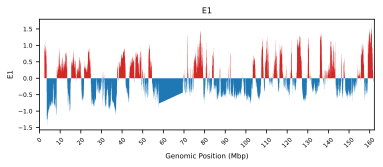

In [3]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots()

x_stair = np.zeros(2*df.start.shape[0])
y_stair = np.zeros(2*df.shape[0])
x_stair[0::2] = df.start
x_stair[1::2] = df.start + resolution
y_stair[0::2] = df.e1
y_stair[1::2] = df.e1


ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

ax.set_xlim(0, df["start"].max()+resolution)
ticks = np.arange(0, df["start"].max()+resolution, step=1e7, dtype=int)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks/1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1");

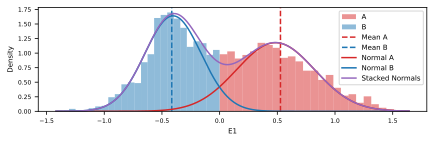

In [4]:
# Histogram of distribution of E1 values (A and B)

x = df["start"].values
y = df["e1"].values

f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=25, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=25, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = np.median(y[y>0])
mean_b = np.median(y[y<0])
std_a = y[y>0].std()
std_b = y[y<0].std()

ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

### Model Specification

Here, the structure of the model is as follows:

We keep the assumption that the E1 values can be drawn from two Gaussian priors, one for A compartments and one for B compartments. To introduce spatial dependency, we use rolling regression with a Gaussian Random Walk (GRW) prior on the latent state variable (`p`) that is then squished through a sigmoid function.  

**NB** We only use a GRW on the latent variable in this model as a simpler alternative GRW on the E1. Guess what comes next.

**Notation** 

Let: 
- $y_i$: Observed E1 value at bin $i$
- $ z_i \in \{0, 1\} $: Latent compartment assignment (0 = B, 1 = A)
- $ \mu_A, \mu_B $: Mean E1 values for compartments A and B
- $ \sigma $: Shared standard deviation across bins
- $ p $: Prior probability of a bin belonging to compartment A

**Model Variables**

$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \text{HalfNormal}(1) \\
logit(p) &\sim \text{GaussianRandomWalk}(\sigma) \\
p_i &\sim \text{Sigmoid}(logit(p)) \\
z_i &\sim \text{Bernoulli}(p_i) \\
\mu_i &= z_i \cdot \mu_A + (1 - z_i) \cdot \mu_B \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
$$

### PyMC

In [5]:
with pm.Model(coords={"pos": df.index.values}) as model:
    """
    Model E1 track as a continous mixture of two normals using a Gaussian Random Walk (GRW) to model the mixing proportions.
    The GRW is applied to the logit space to ensure the mixing proportions are between 0 and 1.
    """
    e1 = pm.Data("e1", df.e1.values, dims="pos")
    n = e1.shape[0]

    mu_a = pm.Normal("mu_a", 0.5, 0.3)
    mu_b = pm.Normal("mu_b", -0.5, 0.3)
    sigma = pm.HalfNormal("sigma", 0.3)

    # GRW over logit space
    grw_sigma = pm.HalfNormal("grw_sigma", 0.1)
    logit_w = pm.GaussianRandomWalk("logit_w", 
                                    sigma=grw_sigma, shape=n, 
                                    init_dist=pm.Normal.dist(mu=0.0, sigma=1.0),  # or a tighter prior if preferred
                                    dims="pos"
                                    )
    w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

    components = pm.Normal.dist(mu = pm.math.stack([mu_a, mu_b]),
                           sigma = sigma, 
                           shape=(2,))

    # Likelihood estimate
    y_hat = pm.Mixture("y_hat", w=pm.math.stack([w,1-w], axis=1), comp_dists=components, observed=e1, dims='pos')


#### Model graph

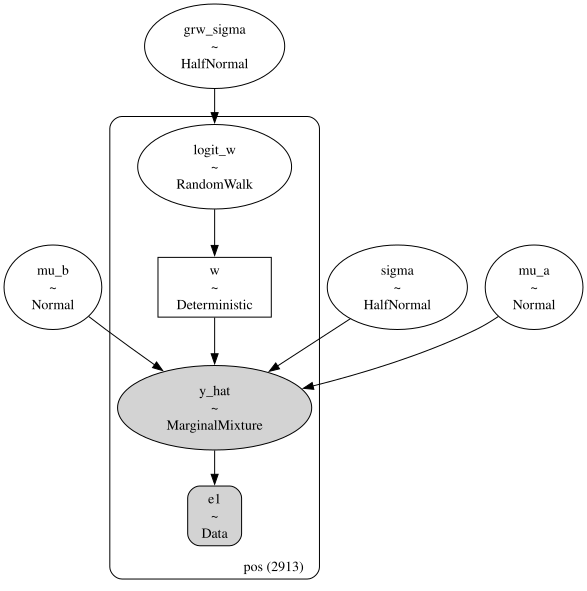

In [6]:
# Visualize
display(model.to_graphviz())


In [7]:
with model:
    # Sample from the prior
    idata = pm.sample_prior_predictive(samples=1000)

idata

Sampling: [grw_sigma, logit_w, mu_a, mu_b, sigma, y_hat]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [8]:
prior_predictive_e1 = az.extract(idata, group="prior_predictive", var_names=["y_hat"])

print(f"""
y_hat (min, max, std): {prior_predictive_e1.values.min(), prior_predictive_e1.values.max(), prior_predictive_e1.values.std()}
""")

#y_lik_norm (min, max, std): {prior_predictive_e1.y_lik_norm.values.min(), prior_predictive_e1.y_lik_norm.values.max(), prior_predictive_e1.y_lik_norm.values.std()}


y_hat (min, max, std): (np.float64(-4.491156497141034), np.float64(4.514739061698418), np.float64(0.6524481241592355))



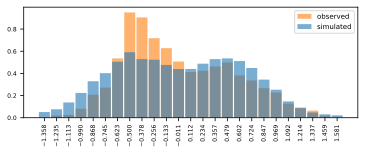

In [9]:
e1_obs = df['e1'].values

az.plot_dist(
    e1_obs,
    kind="hist",
    color="C1", 
    hist_kwargs={"alpha": 0.6,  "bins": 25},
    label="observed"
)



prior_pred_obs = idata.prior_predictive["y_hat"].stack(sample=("chain", "draw")).values
prior_pred_obs = prior_pred_obs[prior_pred_obs > e1_obs.min()]  # Constrain the range to observed values
prior_pred_obs = prior_pred_obs[prior_pred_obs < e1_obs.max()]  # Constrain the range to observed values

az.plot_dist(
    prior_pred_obs,
    kind="hist",
    hist_kwargs={"alpha": 0.6, "bins":25},
    label="simulated",
)
plt.xticks(rotation=90);



#### Posterior sampling


In [10]:
with model:
    # Sample from the posterior
    trace = pm.sample(1000, tune=2000, cores=8, chains=8, target_accept=0.99)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [mu_a, mu_b, sigma, grw_sigma, logit_w]


Output()

Sampling 8 chains for 2_000 tune and 1_000 draw iterations (16_000 + 8_000 draws total) took 1377 seconds.
There were 106 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 4 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 5 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 6 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 7 reached the maximum tree depth

In [11]:

idata.extend(trace)

In [12]:
idata


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

array([[<Axes: title={'center': 'mu_a'}>,
        <Axes: title={'center': 'mu_a'}>],
       [<Axes: title={'center': 'mu_b'}>,
        <Axes: title={'center': 'mu_b'}>],
       [<Axes: title={'center': 'grw_sigma'}>,
        <Axes: title={'center': 'grw_sigma'}>]], dtype=object)

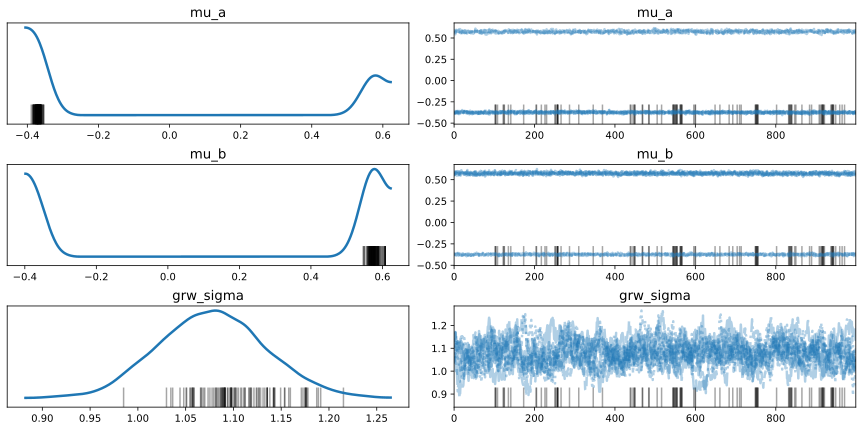

In [13]:
az.plot_trace(idata, var_names=['mu_a','mu_b', 'grw_sigma'], combined=True, backend_kwargs={'layout': 'tight'})

In [14]:
az.summary(idata, var_names=['mu_a','mu_b', 'grw_sigma'], kind='stats', round_to=2)

,mean,sd,hdi_3%,hdi_97%
mu_a,-0.02,0.46,-0.39,0.59
mu_b,0.22,0.46,-0.39,0.59
grw_sigma,1.08,0.06,0.98,1.19


In [15]:
with model:
    # Posterior predictive checks
    ppc = pm.sample_posterior_predictive(idata, var_names=["y_hat"], random_seed=42, extend_inferencedata=True)


Sampling: [y_hat]


Output()

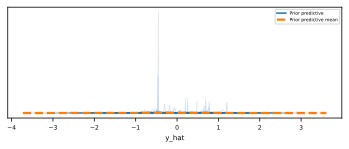

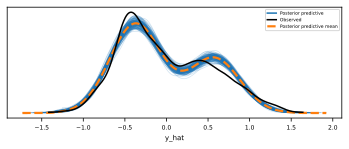

In [16]:
az.plot_ppc(idata, var_names=["y_hat"], num_pp_samples=200, group='prior');
az.plot_ppc(idata, var_names=["y_hat"], num_pp_samples=200);

In [17]:
with model:
    ll = pm.compute_log_likelihood(idata, var_names=["y_hat"])

Output()

In [18]:
az.loo(idata)

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 2913 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -740.29    36.82
p_loo       61.73        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2865   98.4%
   (0.70, 1]   (bad)        47    1.6%
   (1, Inf)   (very bad)    1    0.0%

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


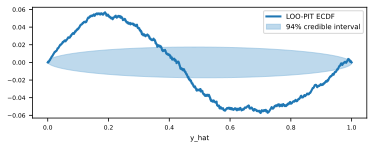

In [19]:
az.plot_loo_pit(idata, y = 'y_hat', ecdf=True, n_unif=1000);

<Axes: title={'center': 'y_hat'}>

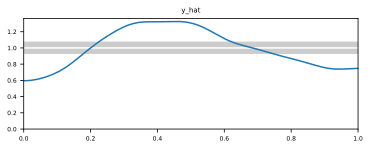

In [20]:
az.plot_bpv(idata)

In [21]:
trace_yhat = az.summary(idata, var_names=["y_hat"], kind="stats", group="posterior_predictive")
trace_yhat

,mean,sd,hdi_3%,hdi_97%
y_hat[47],0.297,0.520,-0.687,1.126
y_hat[48],0.400,0.468,-0.602,1.151
y_hat[49],0.460,0.432,-0.544,1.129
y_hat[50],0.485,0.397,-0.365,1.181
y_hat[51],0.506,0.382,-0.283,1.205
...,...,...,...,...
y_hat[3240],-0.041,0.545,-0.873,0.977
y_hat[3241],-0.013,0.541,-0.868,0.964
y_hat[3242],0.046,0.554,-0.828,1.023
y_hat[3243],0.001,0.548,-0.862,0.985


         mean     sd
means -0.0138  0.353
sds    0.4118  0.073


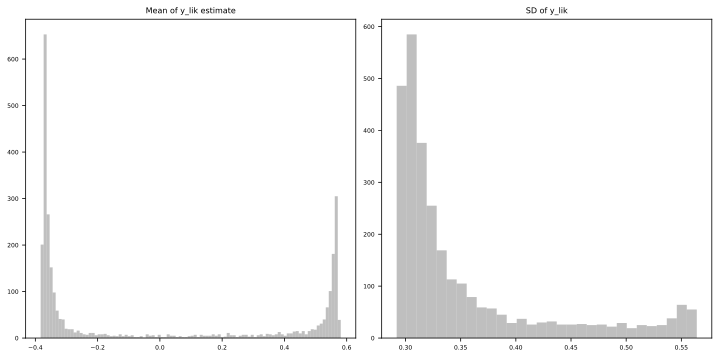

In [22]:
print(pd.DataFrame({
    "mean": [trace_yhat['mean'].mean(), trace_yhat['mean'].std()],
    "sd": [trace_yhat['sd'].mean(), trace_yhat['sd'].std()]
}).set_index(pd.Index(['means', 'sds'])).round(4))

f,ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
ax[0].set_title("Mean of y_lik estimate")
ax[0].hist(trace_yhat['mean'], bins=100, color="tab:grey", alpha=0.5)
#ax[0].set_xlim(-0.05,0.05) # zoom-in on the near-zero peak
ax[1].set_title("SD of y_lik")
ax[1].hist(trace_yhat['sd'], bins=30, color="tab:grey", alpha=0.5)
plt.tight_layout()

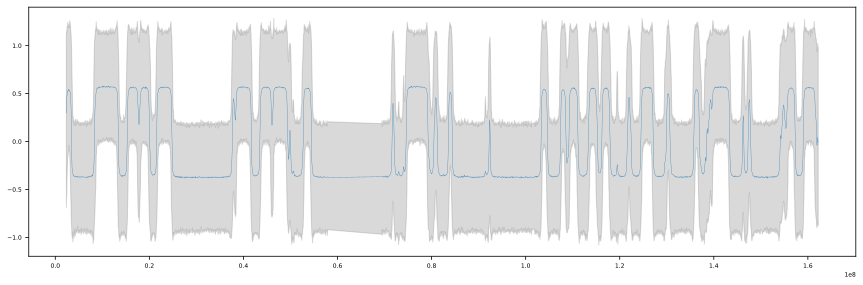

In [23]:
f,ax = plt.subplots(figsize=(12,4))
ax.plot(df['start'], trace_yhat['mean'], lw=0.3, label="prediction confidence")
ax.fill_between(df['start'], trace_yhat['hdi_97%'], trace_yhat['hdi_3%'], color="tab:grey", alpha=0.3, label="95% HDI")
plt.tight_layout()


In [24]:
idata.posterior_predictive.stack(sample=("chain", "draw"))

<xarray.Dataset> Size: 187MB
Dimensions:  (pos: 2913, sample: 8000)
Coordinates:
  * pos      (pos) int64 23kB 47 48 49 50 51 52 ... 3240 3241 3242 3243 3244
  * sample   (sample) object 64kB MultiIndex
  * chain    (sample) int64 64kB 0 0 0 0 0 0 0 0 0 0 0 ... 7 7 7 7 7 7 7 7 7 7 7
  * draw     (sample) int64 64kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y_hat    (pos, sample) float64 186MB 0.747 0.2438 ... -0.06025 0.5158
Attributes:
    created_at:                 2025-06-17T17:02:16.857047+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.22.0

In [25]:
y_ppc = idata.posterior_predictive["y_hat"]

y_ppc_flat = y_ppc.stack(sample=("chain", "draw"))


ppc_mean = y_ppc_flat.mean(dim="sample").values       # mean of predictions per bin
ppc_std = y_ppc_flat.std(dim="sample").values         # predictive std (uncertainty)
ppc_hdi = az.hdi(y_ppc, hdi_prob=0.95)   

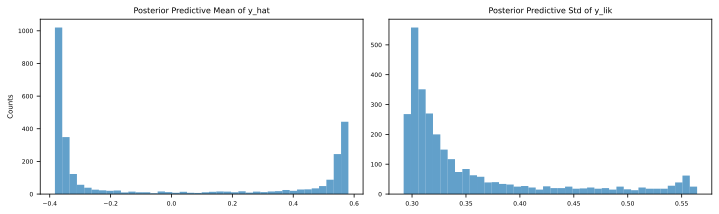

In [26]:
f,ax= plt.subplots(1,2, figsize=(10, 3))
ax[0].set_title("Posterior Predictive Mean of y_hat")
ax[0].set_ylabel("Counts")
ax[0].hist(ppc_mean, bins=40, alpha=0.7, label="Mean(y_hat)")
ax[1].set_title("Posterior Predictive Std of y_lik")
ax[1].hist(ppc_std, bins=40, alpha=0.7, label="Std(y_hat)")
plt.tight_layout()


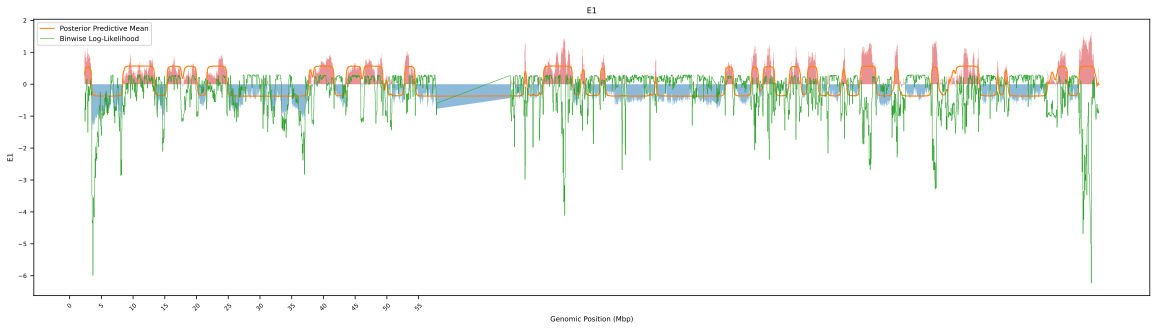

In [27]:
# ppc_mean: shape (bins,)
# mean_ll: shape (bins,)

posterior_mean = idata.posterior_predictive["y_hat"].mean(dim=["chain", "draw"]).values
mean_ll = idata.log_likelihood.y_hat.mean(dim=["chain", "draw"]).values
x = df.start.values
y = df.e1.values

# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(20, 5))

# Stairs
x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", alpha=0.5, ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", alpha=0.5, ec='None')

# plot the y_ppc_flat mean
post_mean_stairs = np.zeros(2*y.shape[0])
post_mean_stairs[0::2] = posterior_mean
post_mean_stairs[1::2] = posterior_mean
ax.plot(x_stair, post_mean_stairs, lw=1, label="Posterior Predictive Mean", color="tab:orange")

# Plot the point-wise log-likelihood
ll_stair = np.zeros(2*mean_ll.shape[0])
ll_stair[0::2] = mean_ll
ll_stair[1::2] = mean_ll
ax.plot(x_stair, ll_stair, lw=0.5, label="Binwise Log-Likelihood", color="tab:green")

# ax.set_xlim(0, 57_984_683 + resolution)
ticks = np.arange(0, 57_984_683, step=5_000_000)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks / 1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1")
ax.legend(loc="best");

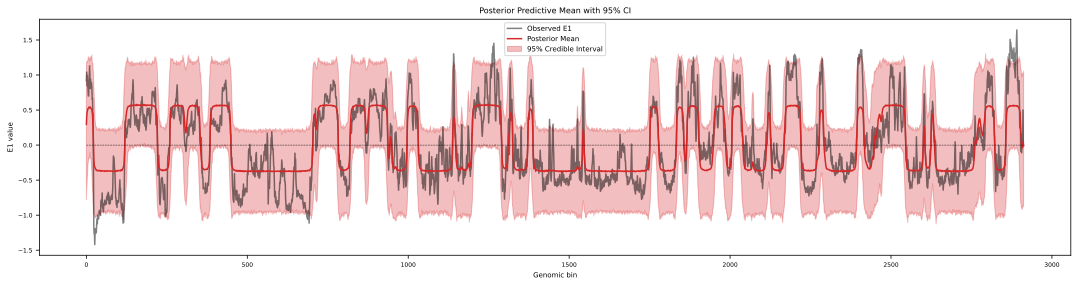

In [28]:
bins = np.arange(len(y))

plt.figure(figsize=(15, 4))

# Observed data
plt.plot(bins, y, label="Observed E1", color="black", alpha=0.5)

# Posterior predictive mean
plt.plot(bins, ppc_mean, label="Posterior Mean", color="tab:red")

# Credible interval shading
plt.fill_between(
    bins,
    ppc_hdi.y_hat.sel(hdi='lower').values,
    ppc_hdi.y_hat.sel(hdi='higher').values,
    color="tab:red",
    alpha=0.3,
    label="95% Credible Interval"
)

plt.hlines(0, xmin=0, xmax=bins.shape[0], color='black', linestyle='--', linewidth=0.5)

plt.xlabel("Genomic bin")
plt.ylabel("E1 value")
plt.title("Posterior Predictive Mean with 95% CI")
plt.legend()
plt.tight_layout()
plt.show()
